In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture
from skimage.color import rgb2gray

In [4]:
cap=cv2.VideoCapture('/content/traffic.avi')

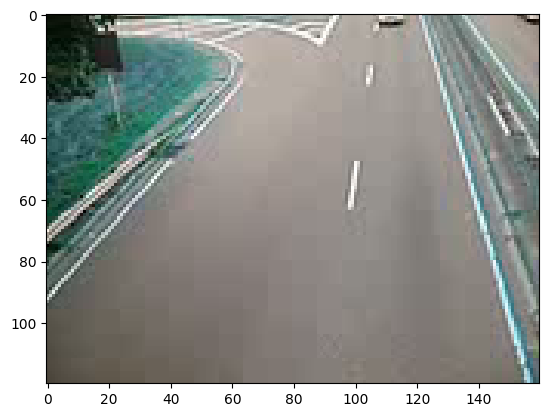

In [5]:
r,f = cap.read()
plt.imshow(f)

In [10]:
frames = []
number_of_frames =0
cap=cv2.VideoCapture('/content/traffic.avi')
while True:
  r,f=cap.read()
  if f is not None:
    frames.append(f)
    number_of_frames+=1
  else:
    break


In [11]:
print(number_of_frames)

120


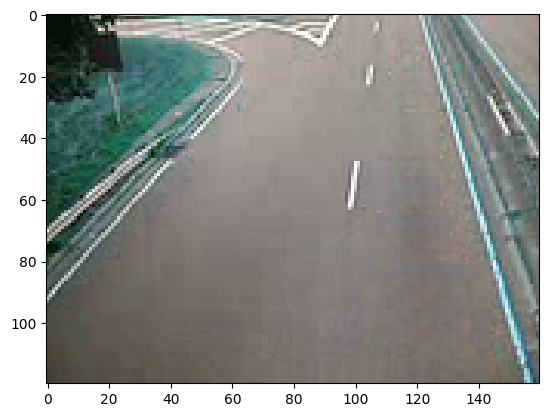

In [13]:
plt.imshow(frames[119])

In [20]:
frames=np.array(frames)
cap=cv2.VideoCapture('/content/traffic.avi')
r,f = cap.read()
rows,cols,ch=f.shape
display(rows, cols,ch)

120

160

3

In [22]:
gmm=GaussianMixture(n_components=3)
cap=cv2.VideoCapture('/content/traffic.avi')
n=10
background=np.zeros((rows,cols,ch))
for r in range(rows):
  for c in range(cols):
    for k in range(ch):
      temp=frames[0:n,r,c,k]
      temp=temp.reshape(n,1)
      gmm.fit(temp)
      means=gmm.means_
      weights=gmm.weights_
      sequence=np.argmax(weights)
      b=int(means[sequence][0])
      background[r,c,k]=b

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/

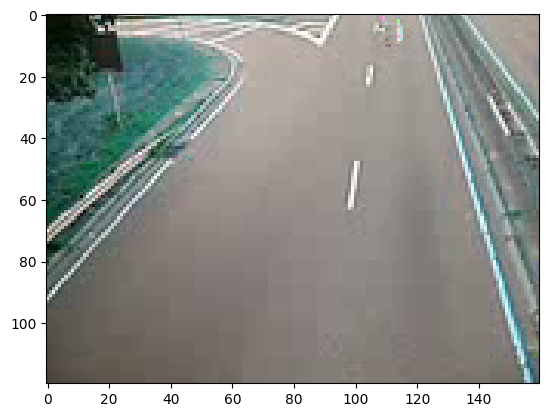

In [25]:
background=background/np.max(background)
plt.imshow(background)

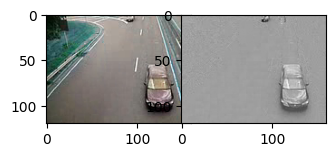

In [34]:
plt.subplot(3,1,1)
plt.imshow(frames[50])
plt.subplot(3,2,2)
foreground50=rgb2gray(frames[50])-rgb2gray(background)
plt.imshow(foreground50,cmap='gray')


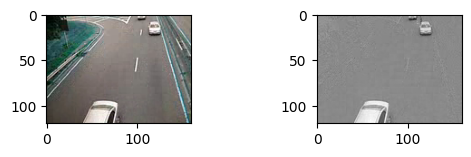

In [35]:
plt.subplot(3,2,3)
plt.imshow(frames[80])
plt.subplot(3,2,4)
foreground80=rgb2gray(frames[80])-rgb2gray(background)
plt.imshow(foreground80,cmap='gray')

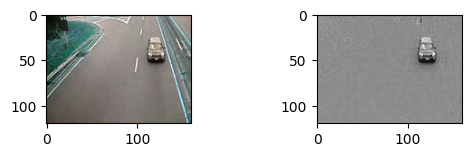

In [37]:
plt.subplot(3,2,5)
plt.imshow(frames[110])
plt.subplot(3,2,6)
foreground110=rgb2gray(frames[110])-rgb2gray(background)
plt.imshow(foreground110,cmap='gray')

CONCLUSION

GMM is used to determine the background frame for first 10 frames of the given video .The background subtraction method shows only cars on 50th ,80th and 110th frame .The same can be reperted for all frame to track the movement for car in entire video . All the frame can be converted to video to track the motion of moving cars